# Import packages

In [7]:
# import all necessary packages
import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sns
import networkx as nx
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# Data Selection & Download from yfinance

In [8]:
# S&P 500 ticker lists from: https://datahub.io/core/s-and-p-500-companies
tickers_list = pd.read_csv("/content/constituents.csv")
symbols = (
    tickers_list["Symbol"]
    .str.replace(".", "-", regex=False)
    .dropna()             # optional cleanup
    .tolist()             # convert to Python list
)
symbols = [s for s in symbols if s != 'GOOG']

In [9]:
tickers_list

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989
...,...,...,...,...,...,...,...,...
498,XYL,Xylem Inc.,Industrials,Industrial Machinery & Supplies & Components,"White Plains, New York",2011-11-01,1524472,2011
499,YUM,Yum! Brands,Consumer Discretionary,Restaurants,"Louisville, Kentucky",1997-10-06,1041061,1997
500,ZBRA,Zebra Technologies,Information Technology,Electronic Equipment & Instruments,"Lincolnshire, Illinois",2019-12-23,877212,1969
501,ZBH,Zimmer Biomet,Health Care,Health Care Equipment,"Warsaw, Indiana",2001-08-07,1136869,1927


In [10]:
ticker_info = tickers_list.set_index("Symbol")
sectors = ticker_info['GICS Sector'].unique()
sector_colors = {
    'Energy':                 '#f28e2b',  # orange
    'Industrials':            '#4e79a7',  # blue
    'Information Technology': '#e15759',  # red
    'Financials':             '#76b7b2',  # teal
    'Health Care':            '#59a14f',  # green
    'Consumer Discretionary': '#edc948',  # yellow
    'Consumer Staples':       '#b07aa1',  # purple
    'Materials':              '#ff9da7',  # pink
    'Real Estate':            '#9c755f',  # brown
    'Utilities':              '#bab0ac',  # grey
    'Communication Services': '#d4a6c8',  # light purple
}

In [11]:
sectors

array(['Industrials', 'Health Care', 'Information Technology',
       'Utilities', 'Financials', 'Materials', 'Consumer Discretionary',
       'Real Estate', 'Communication Services', 'Consumer Staples',
       'Energy'], dtype=object)

In [12]:
tickers = symbols
data = yf.download(tickers, start="2025-02-27", end="2026-04-24", auto_adjust=True)

# Step 2: Select only the Close prices
close_prices = data['Close']

# Step 3: Compute daily returns
returns = close_prices.pct_change().dropna()

[*********************100%***********************]  502 of 502 completed
/tmp/ipykernel_20970/1557263867.py:8: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = close_prices.pct_change().dropna()


In [13]:
returns

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2025-10-28,-0.005048,0.000707,-0.002149,-0.008213,-0.004482,-0.014196,0.010288,0.005897,-0.015061,-0.009203,...,-0.011657,-0.036591,-0.010782,-0.007849,0.007363,0.000374,-0.013219,-0.019201,-0.116753,-0.014370
2025-10-29,-0.018169,0.002602,-0.010548,-0.011952,-0.017218,0.013338,-0.022104,-0.061265,-0.018007,-0.013850,...,-0.022747,0.000166,-0.001629,0.012345,0.016279,-0.045772,-0.013467,-0.014139,-0.012905,-0.010109
2025-10-30,0.001117,0.006303,0.013592,-0.001107,0.001929,0.009202,0.006054,0.004085,-0.009105,0.002809,...,0.013362,-0.009101,0.023842,-0.015114,-0.009284,-0.033852,-0.000934,-0.001504,-0.034716,0.001111
2025-10-31,0.020926,-0.003795,-0.044522,0.001583,-0.008422,-0.003809,0.003410,0.003154,0.005281,-0.002636,...,-0.021693,-0.006512,-0.005148,-0.002877,-0.004487,0.027327,-0.006112,0.010044,0.030149,0.003412
2025-11-03,-0.011410,-0.004882,-0.027885,0.002055,0.001780,-0.003592,-0.006637,-0.008345,-0.002221,-0.007269,...,-0.021304,0.056643,0.001109,-0.005247,-0.011667,-0.021596,0.008465,-0.006762,0.004940,0.001805
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-17,0.030613,0.025930,-0.002919,0.027139,0.014036,0.005046,0.018814,-0.014950,0.049887,-0.023879,...,0.033251,0.022187,0.000370,-0.036452,-0.032745,0.037717,0.020499,0.000000,0.005965,0.028058
2026-04-20,-0.007467,0.010435,-0.022411,0.014412,-0.008367,-0.001025,-0.013104,0.017100,0.025845,0.019839,...,0.010727,-0.003663,-0.009373,0.008468,-0.005367,0.036907,-0.005959,0.007386,0.012243,0.007140
2026-04-21,0.009342,-0.025197,0.006922,-0.006546,-0.034167,0.013950,-0.003281,-0.005832,-0.015169,0.021354,...,-0.021620,-0.010387,-0.015438,0.004605,-0.003985,-0.028962,-0.009146,-0.029221,-0.002655,-0.036995


In [14]:
total_return = (close_prices.iloc[-1] - close_prices.iloc[0]) / close_prices.iloc[0]
total_return = total_return.dropna()

# ticker - sector
total_return_df = total_return.reset_index()
total_return_df.columns = ["Symbol", "TotalReturn"]
ticker_info_adj = ticker_info.copy()
ticker_info_adj.index = ticker_info_adj.index.str.replace(".", "-", regex=False)


total_return_df["Sector"] = total_return_df["Symbol"].map(
    ticker_info_adj["GICS Sector"]
)

# top 5 tickers for each sector a year before
top5_per_sector = (
    total_return_df
    .dropna(subset=["Sector"])                          # drop tickers with no sector
    .sort_values("TotalReturn", ascending=False)
    .groupby("Sector")
    .head(5)
    .sort_values(["Sector", "TotalReturn"], ascending=[True, False])
)

print(top5_per_sector.to_string(index=False))

# convert to list for use
chosen_tickers = top5_per_sector["Symbol"].tolist()
print(f"\nTotal tickers selected: {len(chosen_tickers)}")
print(chosen_tickers)

Symbol  TotalReturn                 Sector
  SATS     2.996054 Communication Services
   WBD     1.445455 Communication Services
 GOOGL     1.020515 Communication Services
    EA     0.558933 Communication Services
   TKO     0.260522 Communication Services
  CVNA     0.805564 Consumer Discretionary
   TPR     0.769813 Consumer Discretionary
    GM     0.669556 Consumer Discretionary
  ROST     0.665886 Consumer Discretionary
  EBAY     0.659287 Consumer Discretionary
  CASY     0.938822       Consumer Staples
    BG     0.779133       Consumer Staples
    DG     0.694273       Consumer Staples
   ADM     0.556127       Consumer Staples
  MNST     0.493837       Consumer Staples
   APA     1.004415                 Energy
   VLO     0.856851                 Energy
   HAL     0.571871                 Energy
   MPC     0.526168                 Energy
   BKR     0.509783                 Energy
  HOOD     0.712587             Financials
     C     0.671747             Financials
   STT     

In [15]:
pd.DataFrame(top5_per_sector).to_csv()


',Symbol,TotalReturn,Sector\n398,SATS,2.996053839290228,Communication Services\n478,WBD,1.4454545107754795,Communication Services\n213,GOOGL,1.0205147398576,Communication Services\n154,EA,0.5589327596128467,Communication Services\n435,TKO,0.260522134121558,Communication Services\n126,CVNA,0.8055641633052009,Consumer Discretionary\n439,TPR,0.7698127955969998,Consumer Discretionary\n211,GM,0.6695563346557705,Consumer Discretionary\n394,ROST,0.6658859673403466,Consumer Discretionary\n155,EBAY,0.6592867372831658,Consumer Discretionary\n77,CASY,0.9388217623442949,Consumer Staples\n59,BG,0.7791329534012327,Consumer Staples\n137,DG,0.6942725465575138,Consumer Staples\n9,ADM,0.5561269528147437,Consumer Staples\n309,MNST,0.49383667746322035,Consumer Staples\n35,APA,1.004414880492951,Energy\n465,VLO,0.8568509920349785,Energy\n219,HAL,0.5718709473114477,Energy\n312,MPC,0.5261683447836255,Energy\n63,BKR,0.5097831972438633,Energy\n228,HOOD,0.7125871874966764,Financials\n73,C,0.6717472628669807,Fina

In [16]:
# define pre and post periods
compare = ("2025-02-27", "2026-02-27")
pre_crisis = ("2026-01-01", "2026-02-27")
post_crisis = ("2026-02-28", "2026-04-24")


In [17]:
compare_df_full = returns[compare[0]:compare[1]]
prev_df_full = returns[pre_crisis[0]:pre_crisis[1]]
post_df_full = returns[post_crisis[0]:post_crisis[1]]

In [18]:
compare_df = compare_df_full[chosen_tickers]
prev_df = prev_df_full[chosen_tickers]
post_df = post_df_full[chosen_tickers]

# Correlation of stock returns

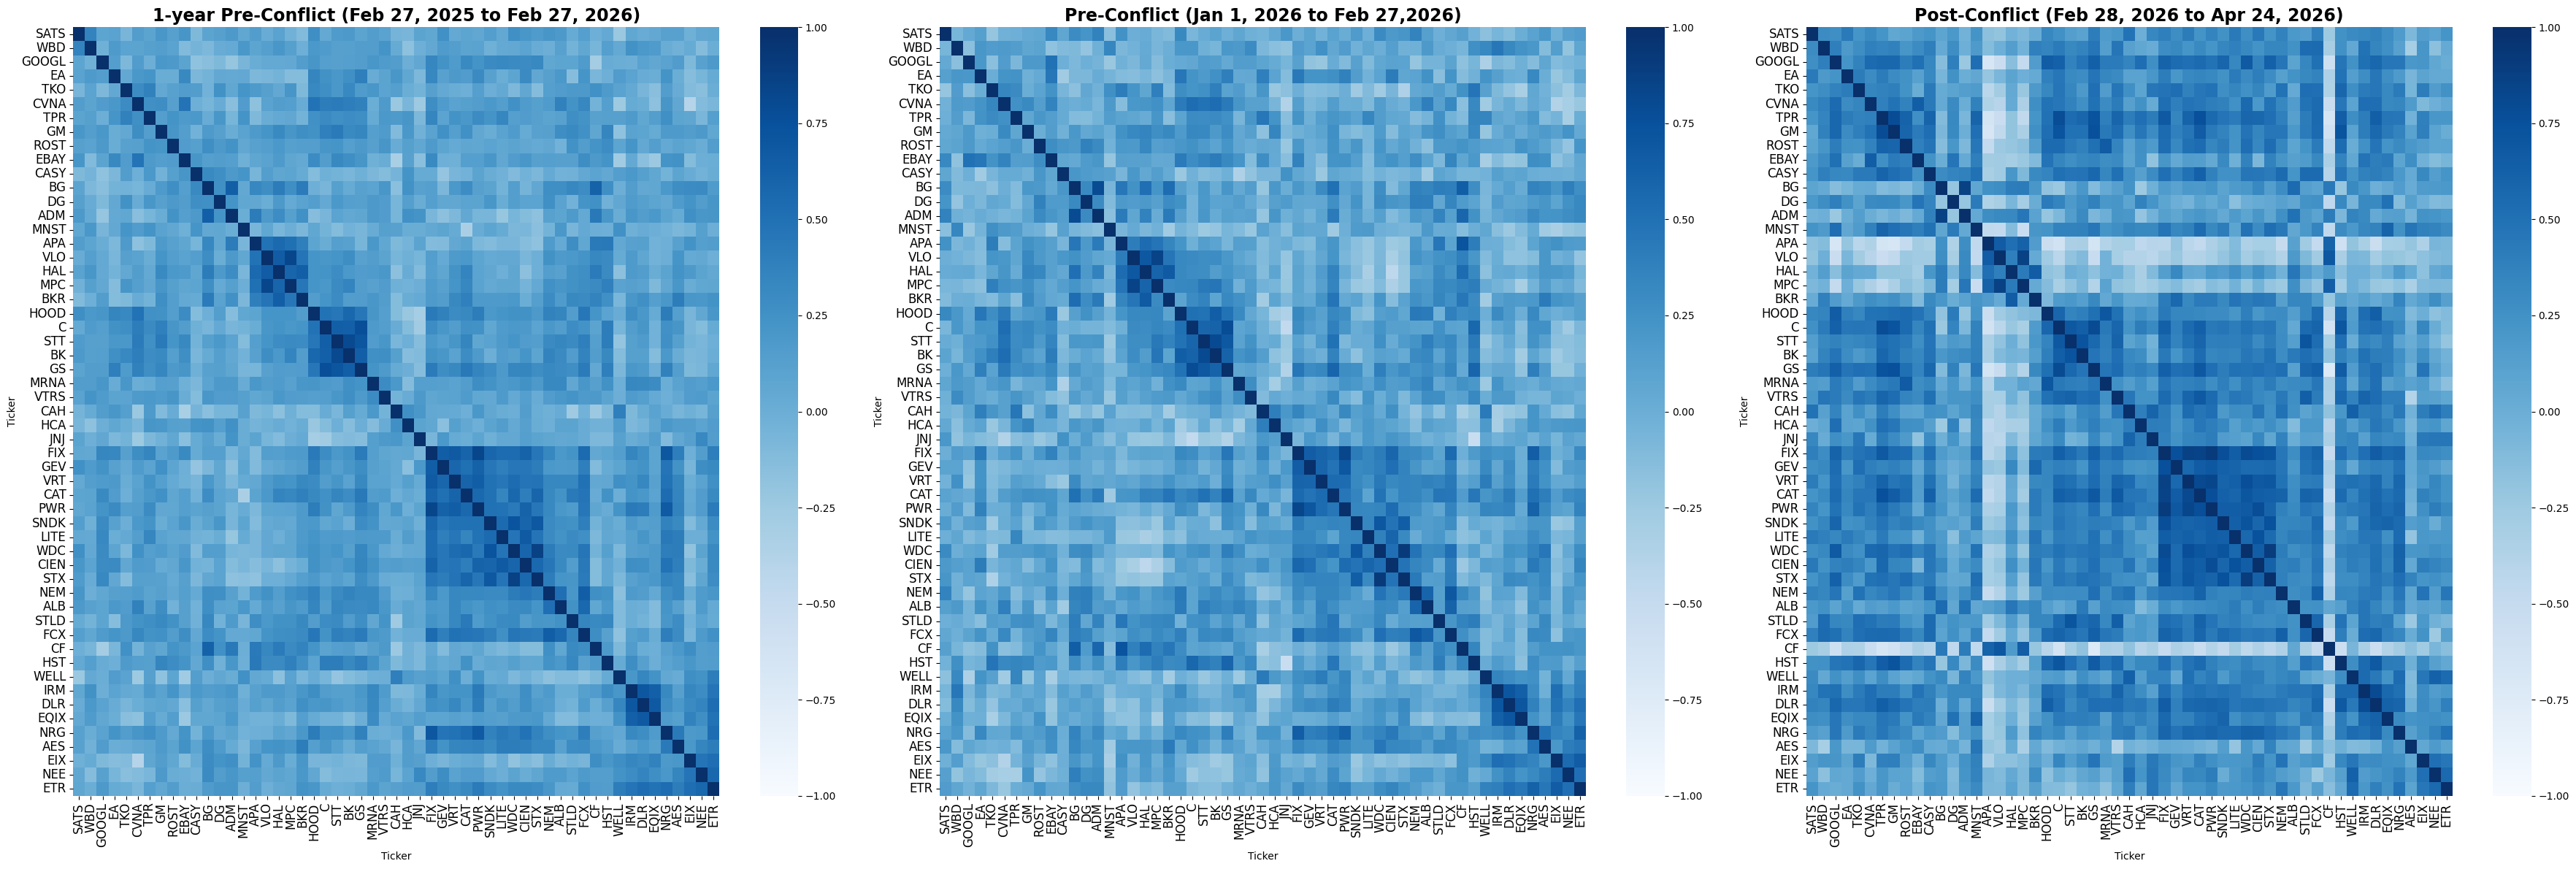

In [19]:
datasets = {
    "1-year Pre-Conflict (Feb 27, 2025 to Feb 27, 2026)": compare_df,
    "Pre-Conflict (Jan 1, 2026 to Feb 27,2026)":  prev_df,
    "Post-Conflict (Feb 28, 2026 to Apr 24, 2026)": post_df,
}

fig, axes = plt.subplots(1, 3, figsize=(36, 12))

for ax, (title, df) in zip(axes, datasets.items()):
    corr = df.corr()
    sns.heatmap(corr, cmap='Blues', ax=ax,
                xticklabels=True, yticklabels=True,
                vmin=-1, vmax=1)

    ax.tick_params(axis='x', labelsize=12, rotation=90)
    ax.tick_params(axis='y', labelsize=12, rotation=0)
    ax.set_title(title, fontsize=17, fontweight='bold')

plt.tight_layout()
plt.show()

# Define network function

In [20]:
# create network graph

def build_plot_network(stock_data, graph_title):
    returns = stock_data.dropna()
    corr_matrix = returns.corr()

    G = nx.Graph()
    valid_tickers = [t for t in tickers if t in corr_matrix.columns]
    G.add_nodes_from(valid_tickers)

    for stock_1 in range(len(corr_matrix.columns)):
        for stock_2 in range(stock_1+1, len(corr_matrix.columns)):
            if corr_matrix.iloc[stock_1, stock_2] > 0.5:
                G.add_edge(corr_matrix.columns[stock_1], corr_matrix.columns[stock_2])



    density = nx.density(G)
    position = nx.spring_layout(G, k=0.25, seed=42)

    edge_x, edge_y = [], []
    for start_pt, end_pt in G.edges():
        x0, y0 = position[start_pt]
        x1, y1 = position[end_pt]
        edge_x.extend([x0, x1, None])
        edge_y.extend([y0, y1, None])

    edge_line = go.Scatter(x=edge_x, y=edge_y, line=dict(width=0.5, color='#888'), hoverinfo='none', mode='lines')

    # Add node details

    node_x, node_y, node_color, node_hover = [], [], [], []
    degrees = dict(G.degree())
    for node in G.nodes():
        x, y = position[node]
        node_x.append(x)
        node_y.append(y)
        if node in ticker_info.index:
          stock = ticker_info.loc[node, 'Security']
          sector = ticker_info.loc[node, 'GICS Sector']
        node_hover.append(f"{node} - {stock} - {sector} - Connections: {degrees[node]}")
        node_color.append(sector_colors.get(sector, '#999999'))

    # Visualize nodes
    node_size = [7 + degrees[node] * 2 for node in G.nodes()]
    node_pt = go.Scatter(
        x=node_x, y=node_y, mode='markers+text', text=list(G.nodes()),
        textposition="top center",
        marker=dict(size=node_size, color=node_color, line=dict(width=1, color='white')),
        hovertext=node_hover, hoverinfo='text'
    )


    fig = go.Figure(
        data=[edge_line, node_pt],
        layout=go.Layout(title=f"{graph_title}",
                         showlegend=False, height=700,
                         xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                         yaxis=dict(showgrid=False, zeroline=False, showticklabels=False))
    )
    return G, fig

In [21]:
compare_G,  compare_graph  = build_plot_network(compare_df, "Network before crisis (1 year before)")
pre_G,  pre_graph  = build_plot_network(prev_df, "Network before crisis (1 month before, from Jan 1, 2026)")
post_G, post_graph = build_plot_network(post_df, "Network during/after crisis (after Feb 28, 2026)")


In [22]:
compare_graph.show()
pre_graph.show()


In [23]:
post_graph.show()

# Community Detection

In [24]:
# add community dectection for pre conflict
communities = nx.community.louvain_communities(pre_G, seed=42)
data = []
for i, comm in enumerate(communities):
    data.append({
        "Community": i + 1,
        "Stocks": ", ".join(map(str, comm))
    })

df = pd.DataFrame(data)
print(df)
df.to_csv()

    Community                                    Stocks
0           1                                       AES
1           2             WDC, FCX, NEM, ALB, STX, SNDK
2           3                                     GOOGL
3           4           GS, C, HST, BK, HOOD, CVNA, STT
4           5      MPC, BG, CF, ADM, HAL, VLO, BKR, APA
5           6                                       CAH
6           7                                      CASY
7           8                                        DG
8           9                                      EBAY
9          10                                      SATS
10         11                                        EA
11         12  PWR, LITE, NRG, FIX, VRT, GEV, CAT, CIEN
12         13                                        GM
13         14                                       HCA
14         15                                       JNJ
15         16                                      MRNA
16         17                                   

',Community,Stocks\n0,1,AES\n1,2,"WDC, FCX, NEM, ALB, STX, SNDK"\n2,3,GOOGL\n3,4,"GS, C, HST, BK, HOOD, CVNA, STT"\n4,5,"MPC, BG, CF, ADM, HAL, VLO, BKR, APA"\n5,6,CAH\n6,7,CASY\n7,8,DG\n8,9,EBAY\n9,10,SATS\n10,11,EA\n11,12,"PWR, LITE, NRG, FIX, VRT, GEV, CAT, CIEN"\n12,13,GM\n13,14,HCA\n14,15,JNJ\n15,16,MRNA\n16,17,MNST\n17,18,"DLR, ETR, EQIX, IRM, EIX, NEE"\n18,19,ROST\n19,20,STLD\n20,21,TPR\n21,22,TKO\n22,23,VTRS\n23,24,WBD\n24,25,WELL\n'

In [25]:
# add community dectection
communities = nx.community.louvain_communities(post_G, seed=42)

data = []
for i, comm in enumerate(communities):
    data.append({
        "Community": i + 1,
        "Stocks": ", ".join(map(str, comm))
    })

df = pd.DataFrame(data)
df.to_csv()

',Community,Stocks\n0,1,AES\n1,2,"HAL, APA, VLO, BKR, CF, MPC"\n2,3,"BG, ALB, ADM"\n3,4,DG\n4,5,"DLR, IRM, CVNA, HOOD, HCA, GOOGL, MRNA, EBAY"\n5,6,SATS\n6,7,EA\n7,8,"CAH, ETR, JNJ, EIX, WELL, NEE"\n8,9,"LITE, PWR, NRG, FIX, VRT, SNDK, GEV, WDC, CIEN, EQIX, STX"\n9,10,"STLD, TKO, STT, WBD, CAT, VTRS, MNST, C, CASY, FCX, NEM, GM, GS, TPR, HST, BK, ROST"\n'